In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import itertools
from scipy import stats
from ephys_utils import test_interaction_pvalues, plot_significance_texts_shifted, process_df_state
import warnings
warnings.filterwarnings("ignore")

In [2]:
def preprocess_plot(df, cat_name , name,  palette, order, plotting = False, identifier = None):
    ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Sag (mV)', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'RI (MΩ)', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

    for column in ls:
        df[column] = pd.to_numeric(df[column])

        if column in ['isi_(ms)', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'AHP_(mV)']:
            param_df = df[df.I_zero != 'silent']
        
        
        else:
            param_df = df
        
        try:
            unique_cat = df[cat_name].unique()
            combos = list(itertools.combinations(unique_cat, 2))

            for combo in combos:
                should_plot = False
                # _, p = stats.ttest_ind(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                #                         param_df[(param_df[cat_name] == combo[1])][column].dropna(),
                #                     equal_var = False)

                _, p = stats.mannwhitneyu(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                                        param_df[(param_df[cat_name] == combo[1])][column].dropna())
            
                print(column, combo, p)
               

           
        except ValueError:
            
            continue

        if plotting:
            try:
                print(param_df.groupby(cat_name)[column].mean())
                

                sns.set(rc={"figure.figsize": (2, 3)})
                sns.set(font_scale=2.5) 
                sns.set_style("ticks")

                ax = sns.boxplot(x=cat_name, y=column, data = param_df, order = order, palette = palette, 
                                saturation=8, linewidth=1.7, showfliers = False, boxprops=dict(alpha=0.5))
                ax = sns.stripplot(x=cat_name, y=column, data = param_df, order=order, 
                                jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = palette, alpha=0.5, zorder=0)
                ax.set_xlabel('')
                plt.xticks(rotation = 45)
                # ax.set_xticklabels( ('Pre', 'Agg+', 'Agg-',  'Y-KD') , rotation=45)
                ax.yaxis.set_major_locator(plt.MaxNLocator(4))
                plt.ylabel(column.replace('_', ' '))

                sns.despine()
                
                plt.savefig(f'output_figures/{column}.png',
                    dpi=300,bbox_inches='tight', transparent=True)
                plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_16/linked_figure_S16/{column}_sampled_{identifier}.pdf',
                    dpi=300,bbox_inches='tight', transparent=True)
                plt.show()
            except KeyError:
                pass

def proportion(df, column1, column2, cols):
    prop = pd.crosstab(df[column1], df[column2], margins = True).reset_index()
    prop = prop.set_index(column1)
    print(prop)
    prop = prop.iloc[:-1, :-1]

    print(stats.fisher_exact(prop))
    
    prop = prop.apply(lambda x: x.div(x.sum()).mul(100), axis=1)
    
    
    prop = prop[cols]
    prop = prop.reset_index()
    return prop

Cm(pF) ('Pre', 'Post') 0.5790997419539189
pre_post_state
Post    40.410829
Pre     37.385992
Name: Cm(pF), dtype: float64


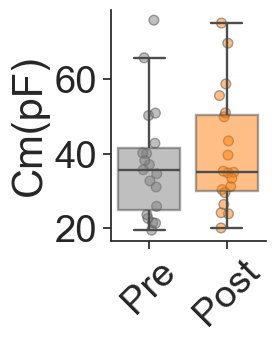

Firing_freq_(Hz)_I0 ('Pre', 'Post') 0.04164018106258195
pre_post_state
Post    0.517200
Pre     1.770379
Name: Firing_freq_(Hz)_I0, dtype: float64


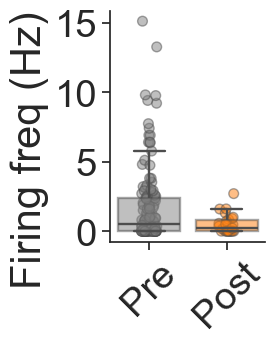

Instant_freq_(Hz) ('Pre', 'Post') 0.028848521020518523
pre_post_state
Post    0.807600
Pre     2.143485
Name: Instant_freq_(Hz), dtype: float64


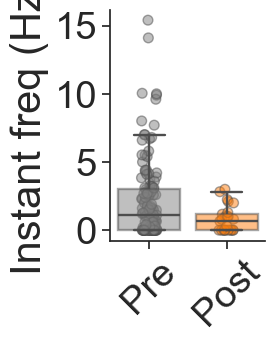

isi_(ms) ('Pre', 'Post') 0.1549490176318414
pre_post_state
Post    1866.371429
Pre     3999.578723
Name: isi_(ms), dtype: float64


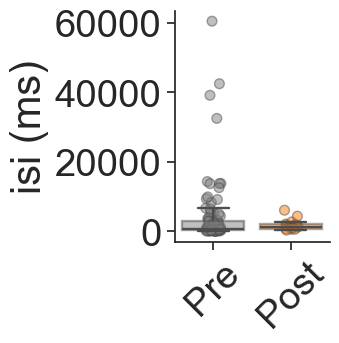

CaT ('Pre', 'Post') 0.6209380971552163
pre_post_state
Post    4.950833
Pre     5.926481
Name: CaT, dtype: float64


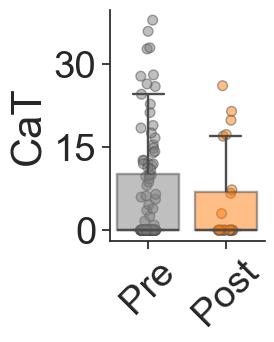

Sag (mV) ('Pre', 'Post') 0.04474162546436981
pre_post_state
Post    3.750417
Pre     7.146852
Name: Sag (mV), dtype: float64


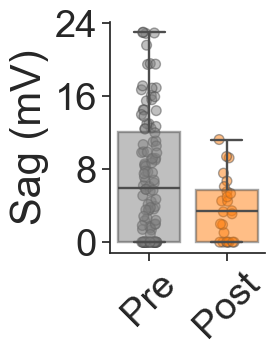

AP_ampl ('Pre', 'Post') 0.32557980161770383
pre_post_state
Post    91.063571
Pre     86.062152
Name: AP_ampl, dtype: float64


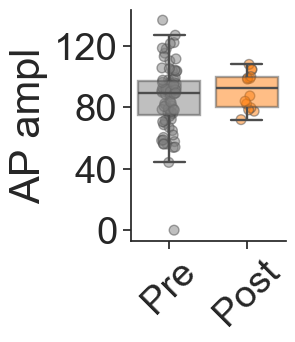

AP_halfwidth ('Pre', 'Post') 0.8819155564485519
pre_post_state
Post    3.222143
Pre     2.942468
Name: AP_halfwidth, dtype: float64


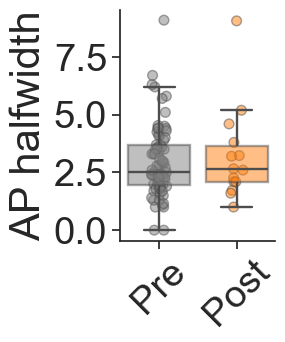

AP_time_to_peak ('Pre', 'Post') 0.3039706586929216
pre_post_state
Post    2.285
Pre     2.615
Name: AP_time_to_peak, dtype: float64


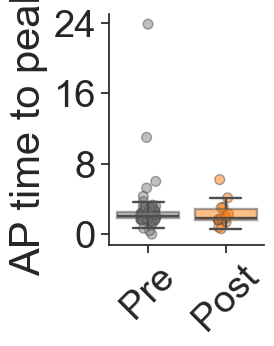

area(mV_ms) ('Pre', 'Post') 0.6558270140698104
pre_post_state
Post    287.642857
Pre     278.371795
Name: area(mV_ms), dtype: float64


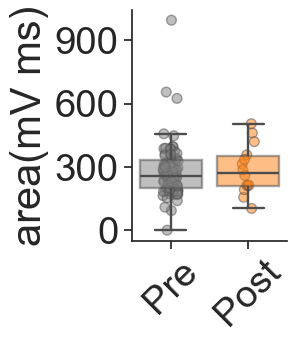

rheobase_at_-60mV_(pA) ('Pre', 'Post') 0.44805942828278433
pre_post_state
Post    24.041667
Pre     16.238095
Name: rheobase_at_-60mV_(pA), dtype: float64


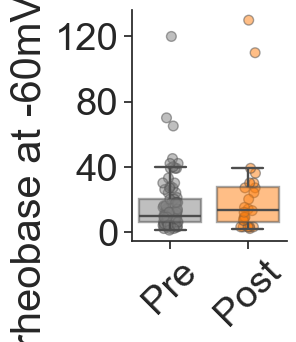

AHP_(mV) ('Pre', 'Post') 0.25596108546269625
pre_post_state
Post   -53.819286
Pre    -50.008205
Name: AHP_(mV), dtype: float64


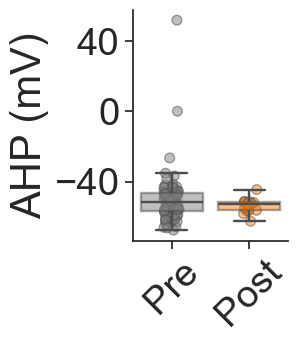

Vm ('Pre', 'Post') 0.46570943008498533
pre_post_state
Post   -48.172121
Pre    -46.233527
Name: Vm, dtype: float64


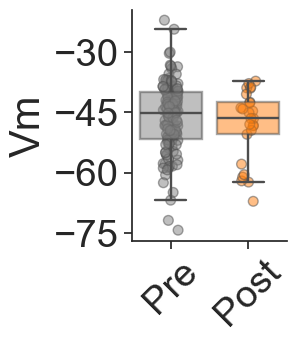

RI (MΩ) ('Pre', 'Post') 0.16288651799802645
pre_post_state
Post    744.169135
Pre     672.075505
Name: RI (MΩ), dtype: float64


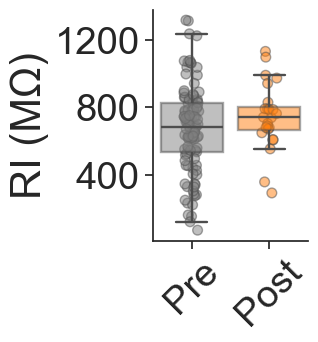

sPSC_frequency ('Pre', 'Post') 0.7260594719247089
pre_post_state
Post    2.02613
Pre     1.71229
Name: sPSC_frequency, dtype: float64


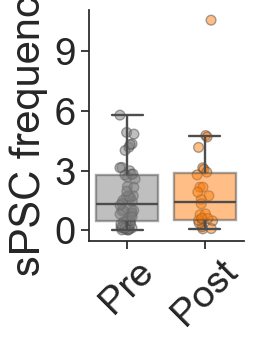

sPSC_Amplitude(pA) ('Pre', 'Post') 0.5991827708223081
pre_post_state
Post    11.695165
Pre     12.360542
Name: sPSC_Amplitude(pA), dtype: float64


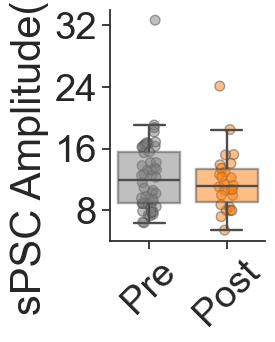

sPSCs_Rise time ('Pre', 'Post') 0.99536721866994
pre_post_state
Post    1.142308
Pre     1.276596
Name: sPSCs_Rise time, dtype: float64


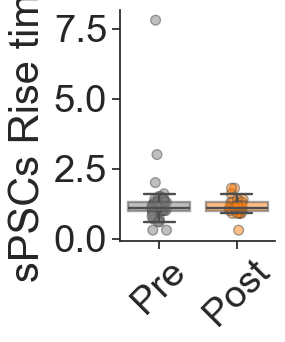

sPSCs (decay) ('Pre', 'Post') 0.7893749944014009
pre_post_state
Post     9.966788
Pre     14.063905
Name: sPSCs (decay), dtype: float64


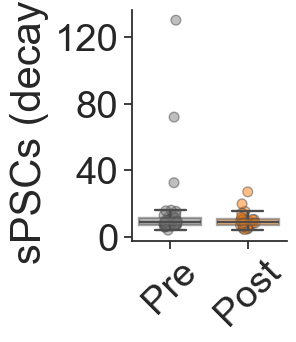

In [3]:
filter_cat = ['Pre', 'Agg+', 'Agg-']

ephys = pd.read_csv('sampled_ephys_data.csv')
ephys['pre_post_state'] = ephys['Behaviour_6hFD'].apply(lambda x: 'Pre' if x == 'Pre' else 'Post')
ephys.rename(columns = {'Input_Resistance': 'RI (MΩ)', 'Ih_at_-120mV': 'Sag (mV)',
                        'filename':'experiment_day'}, inplace = True)


filtered_ephys = ephys[(ephys.Behaviour_6hFD.isin(filter_cat))]
#                        (~ephys.experiment_day.str.contains('2025'))] # just take rachida's data#


filtered_ephys = ephys[(ephys.Behaviour_6hFD.isin(filter_cat)) ]

agg = ephys[ephys.Behaviour_6hFD == 'Agg+']
agg_size = agg.shape[0]
no_agg = ephys[ephys.Behaviour_6hFD == 'Agg-'].sample(n = int(agg_size*0.25), random_state = 40)

estrous_samples = pd.concat([agg, no_agg]).estrous_stage
estrous_samples.loc[estrous_samples == 'P to E'] = 'P' 
estrous_samples.loc[estrous_samples == 'D to P'] = 'D'


# sampled_ephys = pd.concat([filtered_ephys[filtered_ephys.Behaviour_6hFD == 'Pre'], agg, no_agg])



# 1. Create subset of 'Pre' trials
pre_df = filtered_ephys[filtered_ephys.Behaviour_6hFD == 'Pre']

# 2. Get desired distribution from 'estrous_samples'
target_counts = estrous_samples.value_counts(normalize=True)

# 3. Compute desired sample size
n_pre_samples = pre_df.shape[0]  # or set a fixed number if you want
sample_counts = (target_counts * n_pre_samples).astype(int) // 1.5 # keep it to the maximum to make sure that estrous distribution is roughly the same

# 4. Sample from pre_df stratified by estrous_stage
sampled_pre = (
    pre_df.groupby("estrous_stage")
    .apply(lambda x: x.sample(
        n=min(sample_counts.astype(int).get(x.name, 20), len(x)),
        random_state=42
    ))
    .reset_index(drop=True)
)

# 5. Combine all into your final sampled dataset
sampled_ephys = pd.concat([sampled_pre, agg, no_agg])



preprocess_plot(sampled_ephys,'pre_post_state', 'pan', 
                palette=['Gray', 'Tab:orange'], order = ['Pre', 'Post'],
                identifier = None,
                  plotting= True)

pre_post_state  estrous_stage
Pre             D                47
Name: count, dtype: int64
Cm(pF) ('Pre', 'Post') 0.5714285714285714
pre_post_state
Post    49.056072
Pre     31.119800
Name: Cm(pF), dtype: float64


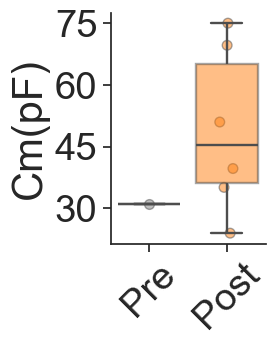

Firing_freq_(Hz)_I0 ('Pre', 'Post') 0.1885367461452978
pre_post_state
Post    0.472000
Pre     1.923191
Name: Firing_freq_(Hz)_I0, dtype: float64


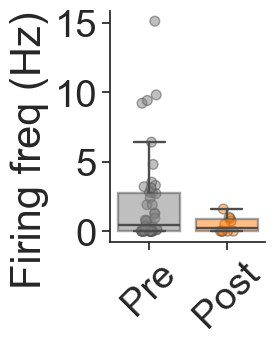

Instant_freq_(Hz) ('Pre', 'Post') 0.14896956434945108
pre_post_state
Post    0.82200
Pre     2.38383
Name: Instant_freq_(Hz), dtype: float64


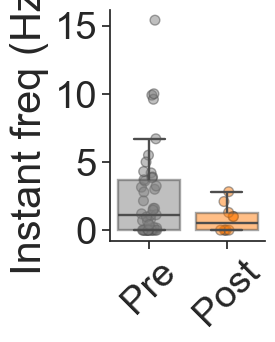

isi_(ms) ('Pre', 'Post') 0.4752040046157693
pre_post_state
Post    1228.00000
Pre     3658.65625
Name: isi_(ms), dtype: float64


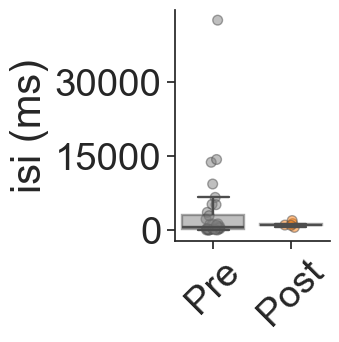

CaT ('Pre', 'Post') 0.14621669824075917
pre_post_state
Post    4.277778
Pre     8.404474
Name: CaT, dtype: float64


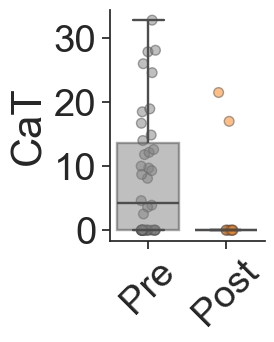

Sag (mV) ('Pre', 'Post') 0.014484744329157941
pre_post_state
Post    2.766667
Pre     8.638158
Name: Sag (mV), dtype: float64


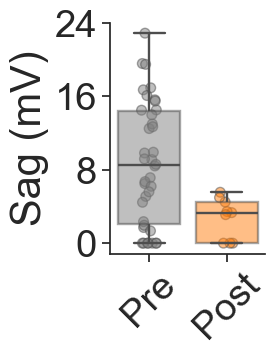

AP_ampl ('Pre', 'Post') 0.6037280605420001
pre_post_state
Post    91.680000
Pre     85.569259
Name: AP_ampl, dtype: float64


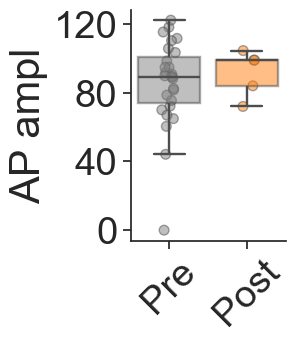

AP_halfwidth ('Pre', 'Post') 0.5038916647600298
pre_post_state
Post    2.3120
Pre     2.5988
Name: AP_halfwidth, dtype: float64


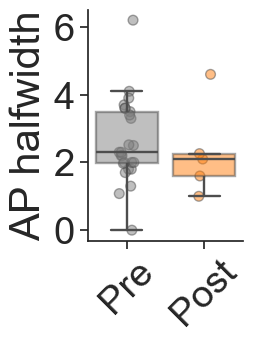

AP_time_to_peak ('Pre', 'Post') 0.12546299411563797
pre_post_state
Post    1.744000
Pre     3.268077
Name: AP_time_to_peak, dtype: float64


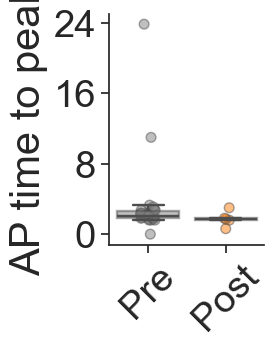

area(mV_ms) ('Pre', 'Post') 0.5837526705157405
pre_post_state
Post    236.00
Pre     295.05
Name: area(mV_ms), dtype: float64


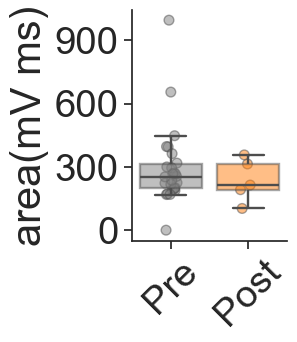

rheobase_at_-60mV_(pA) ('Pre', 'Post') 0.3160089958765263
pre_post_state
Post    18.555556
Pre     14.966667
Name: rheobase_at_-60mV_(pA), dtype: float64


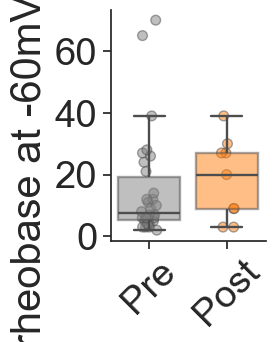

AHP_(mV) ('Pre', 'Post') 0.7676448268235513
pre_post_state
Post   -54.020000
Pre    -50.615769
Name: AHP_(mV), dtype: float64


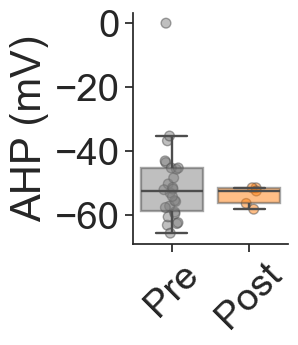

Vm ('Pre', 'Post') 0.6302710575645317
pre_post_state
Post   -48.594431
Pre    -46.988840
Name: Vm, dtype: float64


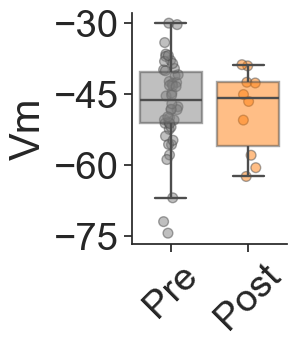

RI (MΩ) ('Pre', 'Post') 0.036139000451453844
pre_post_state
Post    782.414345
Pre     606.510992
Name: RI (MΩ), dtype: float64


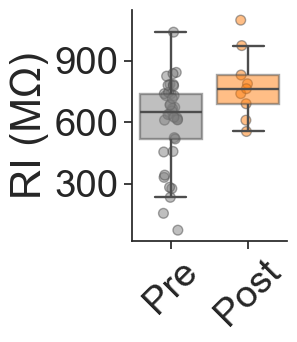

sPSC_frequency ('Pre', 'Post') 0.02058991035319979
pre_post_state
Post    2.634073
Pre     0.631541
Name: sPSC_frequency, dtype: float64


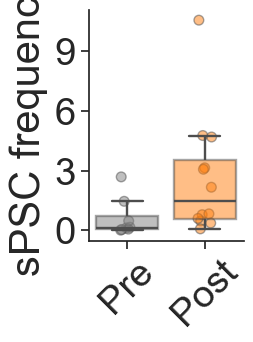

sPSC_Amplitude(pA) ('Pre', 'Post') 0.03142017940779551
pre_post_state
Post    12.604875
Pre      9.036500
Name: sPSC_Amplitude(pA), dtype: float64


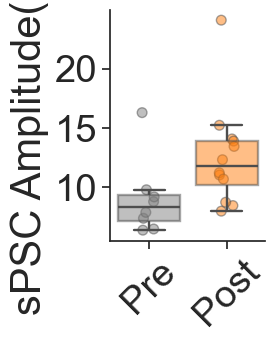

sPSCs_Rise time ('Pre', 'Post') 0.0930984409019887
pre_post_state
Post    1.108333
Pre     2.428571
Name: sPSCs_Rise time, dtype: float64


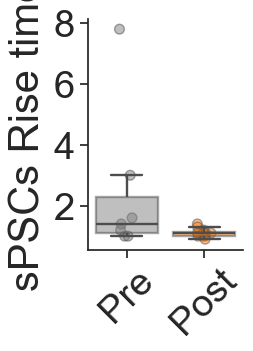

sPSCs (decay) ('Pre', 'Post') 1.0
pre_post_state
Post     9.875917
Pre     10.210000
Name: sPSCs (decay), dtype: float64


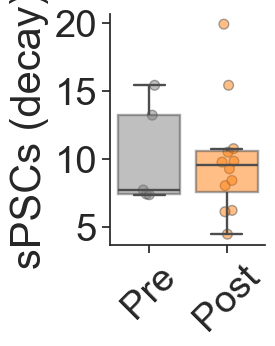

In [4]:
agg = ephys[(ephys.Behaviour_6hFD == 'Agg+') & (ephys.estrous_stage.isin(['D', 'D to P']))]
agg.rename(columns = {'filename': 'experiment_day'}, inplace = True)
agg_size = agg.shape[0]
# no_agg = ephys[(ephys.Behaviour_6hFD == 'Agg-') &
#                (ephys.estrous_stage.isin(['P', 'D to P']))].sample(n = int(agg_size*0.25), random_state = 40)

estrous_samples = agg.estrous_stage
estrous_samples.loc[estrous_samples == 'P to E'] = 'P' 
estrous_samples.loc[estrous_samples == 'D to P'] = 'D'

sampled_pre = filtered_ephys[(filtered_ephys.Behaviour_6hFD == 'Pre')
                             & (filtered_ephys.estrous_stage.isin(['D', 'D to P']))]

print(sampled_pre[['pre_post_state', 'estrous_stage']].value_counts())
# 5. Combine all into your final sampled dataset
sampled_ephys_estrous = pd.concat([sampled_pre, agg], ignore_index=True, axis = 0)


preprocess_plot(sampled_ephys_estrous,'pre_post_state', 'pan', 
                palette=['Gray', 'Tab:orange'], order = ['Pre', 'Post'],
                identifier= 'Diestrous',
                  plotting= True)

Cm(pF) ('Pre', 'Agg-') 0.6828282828282828
Firing_freq_(Hz)_I0 ('Pre', 'Agg-') 0.2031914630399434
Firing_freq_(Hz)_I0 ('Pre', 'agrpkd') 0.18262857885035544
Firing_freq_(Hz)_I0 ('Agg-', 'agrpkd') 0.06395643732128098
Behaviour_6hFD
Agg-      2.808333
Pre       1.821875
agrpkd    0.671250
Name: Firing_freq_(Hz)_I0, dtype: float64


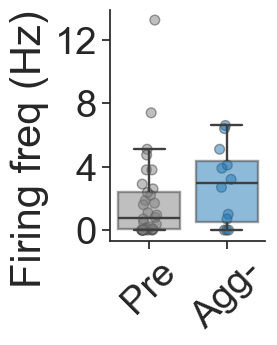

Instant_freq_(Hz) ('Pre', 'Agg-') 0.23287741257582806
Instant_freq_(Hz) ('Pre', 'agrpkd') 0.15615136057563817
Instant_freq_(Hz) ('Agg-', 'agrpkd') 0.07612034487117554
Behaviour_6hFD
Agg-      3.333333
Pre       2.101875
agrpkd    0.845000
Name: Instant_freq_(Hz), dtype: float64


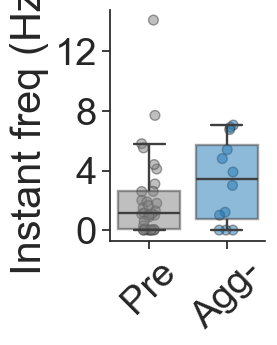

isi_(ms) ('Pre', 'Agg-') 0.026077736353672266
isi_(ms) ('Pre', 'agrpkd') 0.8787840511978442
isi_(ms) ('Agg-', 'agrpkd') 0.050349650349650346
Behaviour_6hFD
Agg-       432.066667
Pre       4070.252000
agrpkd    1168.250000
Name: isi_(ms), dtype: float64


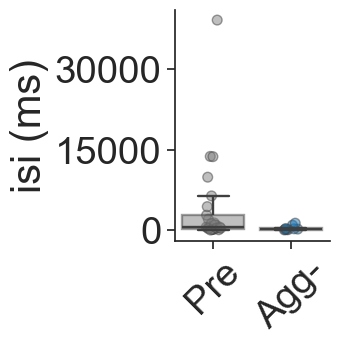

CaT ('Pre', 'Agg-') 0.24197905017626342
CaT ('Pre', 'agrpkd') 0.686350390996187
CaT ('Agg-', 'agrpkd') 0.8451625941965276
Behaviour_6hFD
Agg-      3.194167
Pre       3.022667
agrpkd    3.282857
Name: CaT, dtype: float64


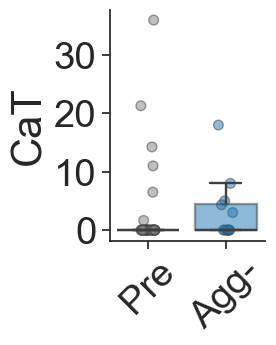

Sag (mV) ('Pre', 'Agg-') 0.3077280308029652
Sag (mV) ('Pre', 'agrpkd') 0.16999647032071563
Sag (mV) ('Agg-', 'agrpkd') 0.0026855211958398497
Behaviour_6hFD
Agg-      7.745000
Pre       6.380968
agrpkd    2.348571
Name: Sag (mV), dtype: float64


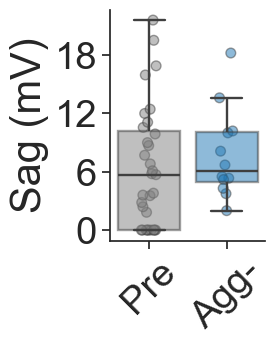

AP_ampl ('Pre', 'Agg-') 0.7548216412327323
AP_ampl ('Pre', 'agrpkd') 0.3097974822112753
AP_ampl ('Agg-', 'agrpkd') 0.1986013986013986
Behaviour_6hFD
Agg-      84.003333
Pre       82.242400
agrpkd    72.225000
Name: AP_ampl, dtype: float64


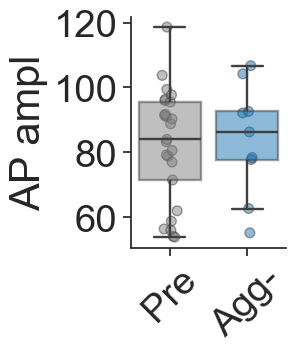

AP_halfwidth ('Pre', 'Agg-') 0.014644387382889512
AP_halfwidth ('Pre', 'agrpkd') 0.7380515508414275
AP_halfwidth ('Agg-', 'agrpkd') 0.032857127694061586
Behaviour_6hFD
Agg-      2.021111
Pre       3.509200
agrpkd    3.466667
Name: AP_halfwidth, dtype: float64


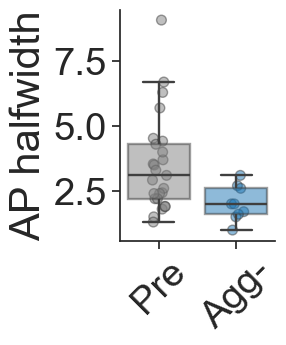

AP_time_to_peak ('Pre', 'Agg-') 0.06628123999035775
AP_time_to_peak ('Pre', 'agrpkd') 0.6578112158257621
AP_time_to_peak ('Agg-', 'agrpkd') 0.075579586158403
Behaviour_6hFD
Agg-      1.923333
Pre       2.516800
agrpkd    2.475000
Name: AP_time_to_peak, dtype: float64


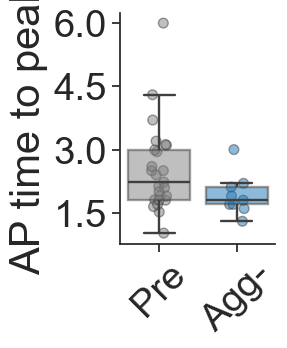

area(mV_ms) ('Pre', 'Agg-') 0.0034147911781178164
area(mV_ms) ('Pre', 'agrpkd') 0.8993308561081785
area(mV_ms) ('Agg-', 'agrpkd') 0.07552447552447553
Behaviour_6hFD
Agg-      184.011111
Pre       289.842400
agrpkd    289.825000
Name: area(mV_ms), dtype: float64


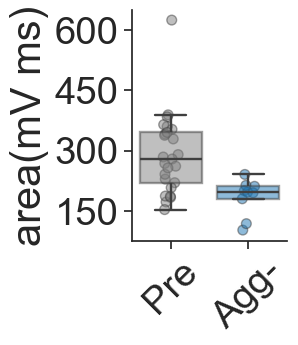

rheobase_at_-60mV_(pA) ('Pre', 'Agg-') 0.060516050846910405
rheobase_at_-60mV_(pA) ('Pre', 'agrpkd') 0.5574237066884393
rheobase_at_-60mV_(pA) ('Agg-', 'agrpkd') 0.05646074401733468
Behaviour_6hFD
Agg-      28.833333
Pre       12.380952
agrpkd     8.428571
Name: rheobase_at_-60mV_(pA), dtype: float64


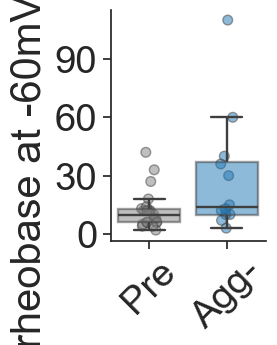

AHP_(mV) ('Pre', 'Agg-') 0.4822081751294438
AHP_(mV) ('Pre', 'agrpkd') 0.5270383677775019
AHP_(mV) ('Agg-', 'agrpkd') 0.413986013986014
Behaviour_6hFD
Agg-     -51.222222
Pre      -45.950400
agrpkd   -47.250000
Name: AHP_(mV), dtype: float64


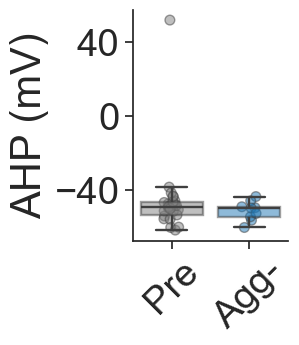

Vm ('Pre', 'Agg-') 0.7220231256429809
Vm ('Pre', 'agrpkd') 0.17425775815868697
Vm ('Agg-', 'agrpkd') 0.42686353893784235
Behaviour_6hFD
Agg-     -47.170981
Pre      -46.051383
agrpkd   -50.630639
Name: Vm, dtype: float64


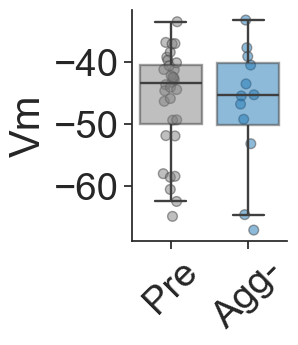

RI (MΩ) ('Pre', 'Agg-') 0.05287124787239247
RI (MΩ) ('Pre', 'agrpkd') 0.31674603114231603
RI (MΩ) ('Agg-', 'agrpkd') 0.012979280781138367
Behaviour_6hFD
Agg-      544.213986
Pre       734.878903
agrpkd    896.595500
Name: RI (MΩ), dtype: float64


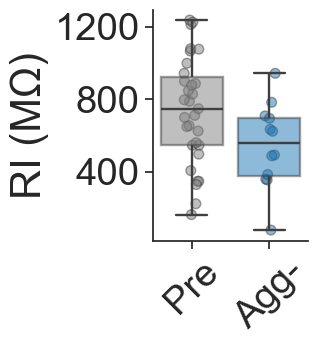

sPSC_frequency ('Pre', 'Agg-') 0.5125185930436823
sPSC_frequency ('Pre', 'agrpkd') 0.9773723860680383
sPSC_frequency ('Agg-', 'agrpkd') 0.5532212885154062
Behaviour_6hFD
Agg-      1.633734
Pre       2.137682
agrpkd    2.160657
Name: sPSC_frequency, dtype: float64


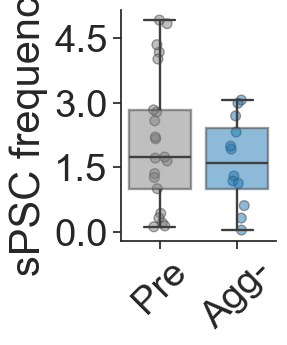

sPSC_Amplitude(pA) ('Pre', 'Agg-') 0.9552259192087166
sPSC_Amplitude(pA) ('Pre', 'agrpkd') 0.20945868275873125
sPSC_Amplitude(pA) ('Agg-', 'agrpkd') 0.27995348319430424
Behaviour_6hFD
Agg-      13.841667
Pre       11.923595
agrpkd     9.683333
Name: sPSC_Amplitude(pA), dtype: float64


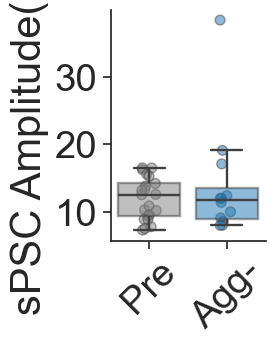

sPSCs_Rise time ('Pre', 'Agg-') 0.13094146841710289
sPSCs_Rise time ('Pre', 'agrpkd') 0.7457492074380494
sPSCs_Rise time ('Agg-', 'agrpkd') 0.41416866612207204
Behaviour_6hFD
Agg-      1.233333
Pre       1.100000
agrpkd    1.216667
Name: sPSCs_Rise time, dtype: float64


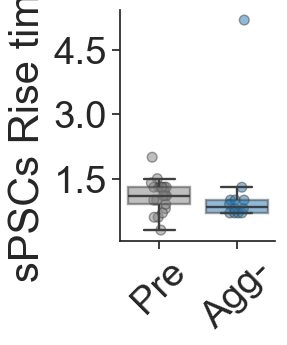

sPSCs (decay) ('Pre', 'Agg-') 0.587309127039823
sPSCs (decay) ('Pre', 'agrpkd') 0.024700721547699003
sPSCs (decay) ('Agg-', 'agrpkd') 0.0008737263689568851
Behaviour_6hFD
Agg-       8.491667
Pre       19.053905
agrpkd    16.983333
Name: sPSCs (decay), dtype: float64


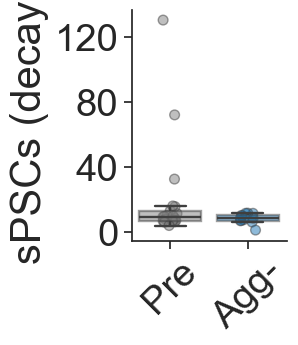

In [5]:
without_agg = ephys[ephys.Behaviour_6hFD != 'Agg+']
preprocess_plot(without_agg[without_agg.estrous_stage == 'P'],'Behaviour_6hFD', 'pan', 
                palette=['Gray', 'Tab:blue'], order = ['Pre', 'Agg-'],
                  plotting= True)

I_zero_reclassified  non_silent  silent  All
pre_post_state                              
Post                         16      11   27
Pre                          97      39  136
All                         113      50  163
SignificanceResult(statistic=0.584817244611059, pvalue=0.25450095417767626)


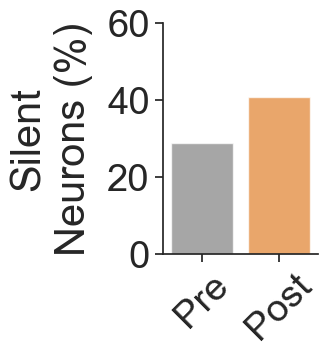

In [6]:
# % silent neurons
cols = ['silent']

cat = ['Pre', 'Agg+', 'Agg-']
sampled_ephys.loc[sampled_ephys['I_zero_reclassified'] != 'silent', 'I_zero_reclassified'] = 'non_silent'
silent_prop = proportion(sampled_ephys[sampled_ephys.Behaviour_6hFD.isin(cat)], 'pre_post_state', 'I_zero_reclassified', cols)
silent_prop['pre_post_state'] = pd.Categorical(silent_prop['pre_post_state'], ['Pre', 'Post'])
silent_prop = silent_prop.sort_values(by = ['pre_post_state'])


sns.set(rc={"figure.figsize": (2, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="pre_post_state", y="silent", order=['Pre', 'Post'], palette = ['gray', 'Tab:orange'], alpha=0.7)
g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('Silent\nNeurons (%)', labelpad=10)
g.set_xticklabels(('Pre', 'Post', r'Agg$^{–}$'), rotation=45)
plt.xlabel('')
plt.ylim(0,60)
plt.title('')
sns.despine(bottom=False)
plt.savefig('output_figures/silent_prop_resampled.png',dpi = 300, bbox_inches = 'tight')
# g.tick_params(bottom=False)
plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_16/linked_figure_S16/silent_proportion_sampled.pdf',
                    dpi=300,bbox_inches='tight', transparent=True)

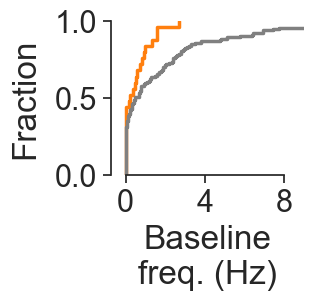

In [7]:
# Firing frequency - VERSION WITH ALL GROUPS

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2)
sns.set_style("ticks")

cum = sns.ecdfplot(
    data=sampled_ephys,
    x="Firing_freq_(Hz)_I0",
    hue="pre_post_state",
    hue_order=['Pre', 'Post'],
    palette=["gray", "tab:orange"],
    linewidth=2.5,
    legend=False,
    stat="proportion",
)
cum.set_xlabel("Baseline\nfreq. (Hz)", labelpad=5)
cum.set_ylabel("Fraction", labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_16/linked_figure_S16/ff_sampled.pdf',
                    dpi=300,bbox_inches='tight', transparent=True)

I_zero_reclassified  non_silent  silent  All
pre_post_state                              
Post                          7       5   12
Pre                          32      15   47
All                          39      20   59
SignificanceResult(statistic=0.65625, pvalue=0.5179347568013896)


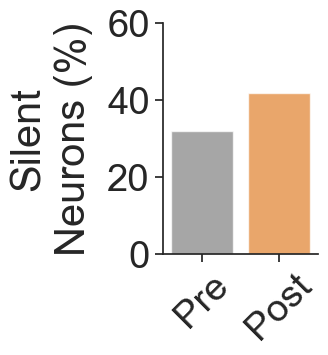

In [8]:
# % silent neurons
cols = ['silent']


sampled_ephys_estrous.loc[sampled_ephys_estrous['I_zero_reclassified'] != 'silent', 'I_zero_reclassified'] = 'non_silent'
silent_prop = proportion(sampled_ephys_estrous, 'pre_post_state', 'I_zero_reclassified', cols)
silent_prop['pre_post_state'] = pd.Categorical(silent_prop['pre_post_state'], ['Pre', 'Post'])
silent_prop = silent_prop.sort_values(by = ['pre_post_state'])


sns.set(rc={"figure.figsize": (2, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="pre_post_state", y="silent", order=['Pre', 'Post'], palette = ['gray', 'Tab:orange'], alpha=0.7)
g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('Silent\nNeurons (%)', labelpad=10)
g.set_xticklabels(('Pre', 'Post'), rotation=45)
plt.xlabel('')
plt.ylim(0,60)
plt.title('')
sns.despine(bottom=False)
plt.savefig('output_figures/silent_prop_estrous_controled.png',dpi = 300, bbox_inches = 'tight')
plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_16/linked_figure_S16/silent_proportion_estrous_sampled_D.pdf',
                    dpi=300,bbox_inches='tight', transparent=True)


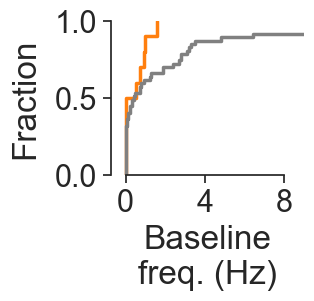

In [9]:
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2)
sns.set_style("ticks")

cum = sns.ecdfplot(
    data=sampled_ephys_estrous,
    x="Firing_freq_(Hz)_I0",
    hue="pre_post_state",
    hue_order=['Pre', 'Post'],
    palette=["gray", "tab:orange"],
    linewidth=2.5,
    legend=False,
    stat="proportion",
)
cum.set_xlabel("Baseline\nfreq. (Hz)", labelpad=5)
cum.set_ylabel("Fraction", labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_16/linked_figure_S16/ff_sampled_D.pdf',
                    dpi=300,bbox_inches='tight', transparent=True)

In [10]:
ramp_path = 'ramps_all.csv'
import os
if os.path.exists(ramp_path):
    df_state = pd.read_csv(ramp_path)

In [11]:
states = ['Pre', 'Agg+', 'Agg-', 'NPY 10nM', 'NPY 100nM', 'NPY Antag', 'NPY1R', 'NPY2R', 'NPY-KD', 'ZD7288']
df_all = process_df_state(df_state, states)


In [12]:
sampled_ephys.rename(columns = {'experiment_day': 'filename'}, inplace = True)
sampled_ephys['filename'] = sampled_ephys['filename'].str.upper()

df_all['filename'] = df_all['filename'].str.replace('.xlsx', '').str.upper()

combined_df = df_all.merge(sampled_ephys, on = 'filename', how = 'inner')


In [13]:
test_df = df_all.merge(sampled_ephys, on = 'filename', how = 'left')
test_df = test_df[test_df['state_x'] == 'Pre']
test_df.loc[test_df['estrous_stage'] == 'P<E', 'estrous_stage'] = 'E'
print(test_df[test_df['estrous_stage'].isna()].filename.unique())
print(test_df[~test_df['estrous_stage'].isin(['P', 'E', 'M', 'D'])].filename.unique())

['S1C1 25052023' 'S1C2 03062025' 'S1C2 14042025' 'S1C2 15012024'
 'S1C2 20032025' 'S1C3 15012024' 'S1C4 02042025' 'S1C4 03062025'
 'S1C4 27062025' 'S1C5 03062025' 'S1C6 03062025' 'S1C6 11062025'
 'S1C6 27062025' 'S1C7 03062025' 'S1C8 03062025' 'S1C9 03062025'
 'S1C1 27072023' 'S2C1 25052023' 'S2C1 24072023']
['S1C1 23112023' 'S1C1 25052023' 'S1C2 03062025' 'S1C2 14042025'
 'S1C2 15012024' 'S1C2 20032025' 'S1C3 15012024' 'S1C4 02042025'
 'S1C4 03062025' 'S1C4 27062025' 'S1C5 03062025' 'S1C6 03062025'
 'S1C6 11062025' 'S1C6 27062025' 'S1C7 03062025' 'S1C8 03062025'
 'S1C9 03062025' 'S1C1 27072023' 'S2C1 25052023' 'S2C1 24072023']


In [14]:
sub_df = combined_df[combined_df["pre_post_state"].isin(("Pre", "Post"))]

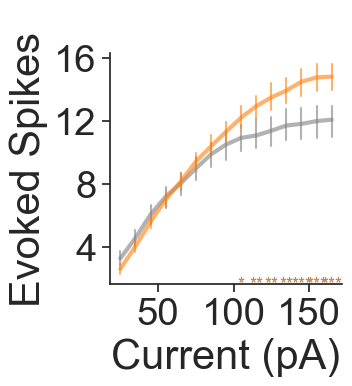

In [27]:
prop = 'num_spike'


result_df = test_interaction_pvalues(
    combined_df,
    prop,
    [("Pre", "Post")],
    state_col="pre_post_state",
    group_var="filename",
    correction=True,
)


sns.set(font_scale=2.5) 
sns.set_style("ticks")

fig, ax = plt.subplots(figsize = [3,3])

palette = ['gray', 'Tab:orange']
# df_all = df_all[df_all.state.isin(['Agg+', 'Pre'])]
combined_df['pre_post_state'] = pd.Categorical(combined_df['pre_post_state'], ['Pre', 'Post'])

sns.lineplot(data=combined_df, x="Injected", y=prop, hue = 'pre_post_state', palette=palette, err_style="bars", ci=58,  
             linewidth=3, alpha=0.6, sort=True)

leg = ax.get_legend()
if leg:
    leg.remove()

ax.set_ylabel("Evoked Spikes")
ax.set_xlabel("Current (pA)")
plt.title('')
# plt.ylim(0,20)
plt.title(" ", pad=10)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
sns.despine(bottom=False)

plot_significance_texts_shifted(
    ax, combined_df, result_df, [("Pre", "Post")], palette, base_y=1, y_shift=0, state_col='pre_post_state',
    
)

plt.savefig(f'output_figures/{prop}_resampled.png',dpi = 300, bbox_inches = 'tight')
plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_16/linked_figure_S16/{prop}_sampled.pdf',
                    dpi=300,bbox_inches='tight', transparent=True)


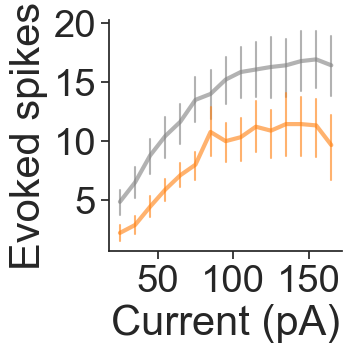

In [28]:
sampled_ephys_estrous.rename(columns = {'experiment_day': 'filename'}, inplace = True)
sampled_ephys_estrous['filename'] = sampled_ephys_estrous['filename'].str.upper()
combined_df = df_all.merge(sampled_ephys_estrous, on = 'filename', how = 'inner')
combined_df['pre_post_state'] = pd.Categorical(combined_df['pre_post_state'], ['Pre', 'Post'])


result_df = test_interaction_pvalues(
    combined_df,
    prop,
    [("Pre", "Post")],
    state_col="pre_post_state",
    group_var="filename",
    correction=True,
)


sns.set(font_scale=2.5) 
sns.set_style("ticks")

prop = 'num_spike'

fig, ax = plt.subplots(figsize = [3,3])

palette = ['gray', 'Tab:orange']
# df_all = df_all[df_all.state.isin(['Agg+', 'Pre'])]

sns.lineplot(data=combined_df, x="Injected", y=prop, hue = 'pre_post_state', palette=palette, err_style="bars", ci=58,  
             linewidth=3, alpha=0.6)

leg = ax.get_legend()
if leg:
    leg.remove()

ax.set_ylabel("Evoked spikes")
ax.set_xlabel("Current (pA)")
plt.title('')
# plt.ylim(0,32)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
sns.despine(bottom=False)

plot_significance_texts_shifted(
    ax, combined_df, result_df, [("Pre", "Post")], palette, base_y=1, y_shift=0, state_col='pre_post_state',
    
)



plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_16/linked_figure_S16/{prop}_sampled_D.pdf',
                    dpi=300,bbox_inches='tight', transparent=True)

In [18]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.mixedlm(
    f"{prop} ~ pre_post_state + Injected",
    combined_df,
    groups=combined_df["filename"],
).fit()

print(model.summary())

              Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    num_spike
No. Observations:      345        Method:                REML     
No. Groups:            23         Scale:                 13.6259  
Min. group size:       15         Log-Likelihood:        -967.6475
Max. group size:       15         Converged:             Yes      
Mean group size:       15.0                                       
------------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
------------------------------------------------------------------
Intercept               5.706    2.337  2.441 0.015   1.125 10.286
pre_post_state[T.Post] -4.803    3.542 -1.356 0.175 -11.746  2.139
Injected[T.35]          1.261    1.089  1.158 0.247  -0.873  3.394
Injected[T.45]          3.261    1.089  2.996 0.003   1.127  5.394
Injected[T.55]          4.826    1.089  4.434 0.000   2.693  6.960
Injected[T

estrous_stage  pre_post_state  Injected
P              Post            25          11
                               35          11
                               45          11
                               55          11
                               65          11
                               75          11
                               85          11
                               95          11
                               105         11
                               115         11
                               125         11
                               135         11
                               145         11
                               155         11
                               165         11
               Pre             25          13
                               35          13
                               45          13
                               55          13
                               65          13
                               75       

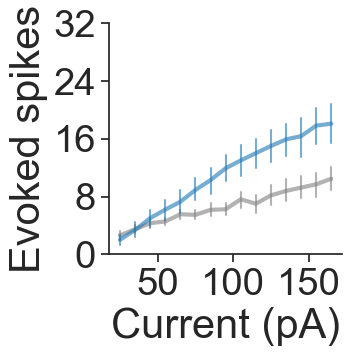

In [19]:
ephys.rename(columns = {'experiment_day': 'filename'}, inplace = True)
ephys['filename'] = ephys['filename'].str.upper()
combined_df = df_all.merge(ephys, on = 'filename', how = 'inner')
combined_df = combined_df[combined_df['Behaviour_6hFD'] != 'Agg+']
print(combined_df[combined_df.estrous_stage == 'P'].groupby(['estrous_stage','pre_post_state', 'Injected']).size())
combined_df['Behaviour_6hFD'] = pd.Categorical(combined_df['Behaviour_6hFD'], ['Pre', 'Agg-'])


sns.set(font_scale=2.5) 
sns.set_style("ticks")

prop = 'num_spike'

fig, ax = plt.subplots(figsize = [3,3])

palette = ['gray', 'Tab:blue']
# df_all = df_all[df_all.state.isin(['Agg+', 'Pre'])]

sns.lineplot(data=combined_df[combined_df.estrous_stage == 'P'], x="Injected", y=prop, hue = 'Behaviour_6hFD', palette=palette, err_style="bars", ci=58,  
             linewidth=3, alpha=0.6)

leg = ax.get_legend()
if leg:
    leg.remove()

ax.set_ylabel("Evoked spikes")
ax.set_xlabel("Current (pA)")
plt.title('')
plt.ylim(0,32)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
sns.despine(bottom=False)
plt.savefig('output_figures/evoked_spikes_estrous_resampled.png',dpi = 300, bbox_inches = 'tight')

In [20]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
# Two-way ANOVA
model = smf.ols('latency ~  C(pre_post_state) * Injected', data=combined_df[combined_df.estrous_stage == 'P']).fit()
anova_results = sm.stats.anova_lm(model, typ=2)

print(anova_results)


                                  sum_sq     df         F        PR(>F)
C(pre_post_state)           1.754761e+05    1.0  4.494837  3.482916e-02
Injected                    2.323531e+06   14.0  4.251246  7.660564e-07
C(pre_post_state):Injected  1.545806e+05   14.0  0.282828  9.953897e-01
Residual                    1.155569e+07  296.0       NaN           NaN
